### ReadMe
This notebook is written for processing the WF dataset
Author: Ruixiang Wu

In [1]:
from tqdm import tqdm

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import sys

In [2]:
# add utils to path
sys.path.append("/home/wrx/WF_GoNogo/utils")
from lib_wrx import show_one_image, show_images
from lib_wrx import images2tiff_two_channel

### read time stamp related to the start and end time of a trial, and water delivery time.

In [3]:
base_dir = "/home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield"
mouse_id = "A095"
session = "20250905"
# config_path = "/home/lsh/WF_GoNogo/config/A095_config.yaml"
rawPath = os.path.join(base_dir, mouse_id, session)
if not os.path.exists(rawPath):
    print(f"The specified path does not exist: {rawPath}")

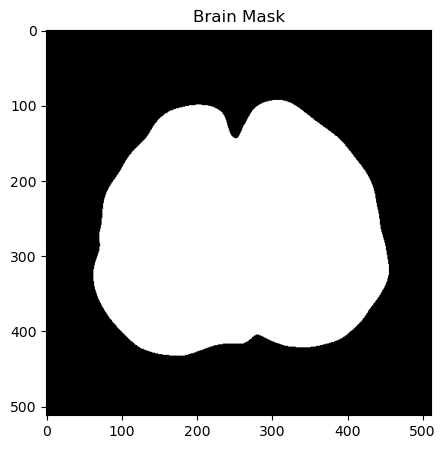

In [4]:
# mask save in ./rawPath/QualityControl/brain_mask.npy
mask_path = os.path.join(rawPath, "QualityControl/brain_mask.npy")
if not os.path.exists(mask_path):
    print(f"The specified mask path does not exist: {mask_path}")

mask = np.load(mask_path)
# print(f"Mask shape: {mask.shape}")
show_one_image(mask, title="Brain Mask")

The number of 470 images: 23641
The number of 405 images: 23640


100%|██████████| 300/300 [00:02<00:00, 149.82it/s]


The shape of the processed images: (300, 2, 512, 512)


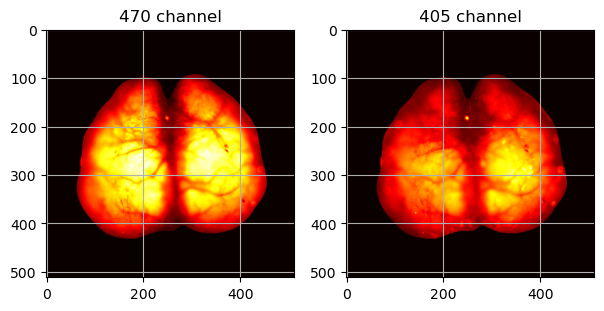

In [5]:
n_preview = 300 # set to None to process all images, 
# or set to an integer to limit the number of images processed for preview

# if mask is not None, apply the mask to the images
stack, files_470 = images2tiff_two_channel(rawPath, n_preview=n_preview,
    mask=mask,)
print("The shape of the processed images:", stack.shape)

# visualize the first image of each channel
images = list(stack[0])
show_images(images, titles=['470 channel', '405 channel'])

(300, 2)
(2,)
detect_lum_outlier: There are dim outliers frames detected!


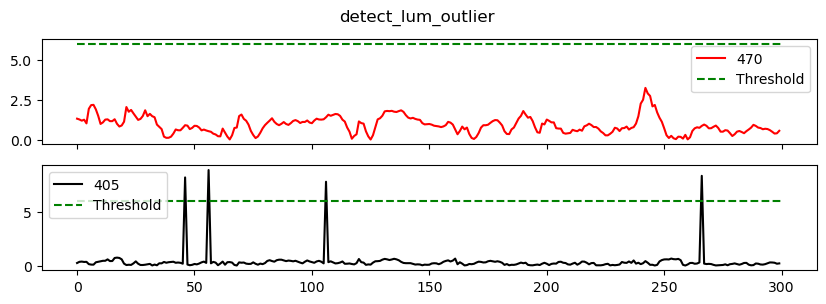

In [6]:
from lib_wrx import detect_lum_outlier
stack_mean = np.mean(stack, axis=(2, 3))
# print("The shape of the stack_mean:", stack_mean.shape)
outlier_index_470, outlier_index_405 = detect_lum_outlier(stack_mean, 
    threshold=6, plot=True)

from lib_wrx import correct_lum_outlier
stack_corrected = correct_lum_outlier(stack, outlier_index_470,
    outlier_index_405, plot=False)

In [7]:
from lib_wrx import delta_ff_3d

# calculate delta_f/f for 470 channel
# the 'delta_ff_3d' is time consuming, optimize 'cal_base' may help
stack_470_dff = delta_ff_3d(stack_corrected[:, 0, :, :], win=150)
# print("The shape of stack_470_dff:", stack_470_dff.shape)

stack_405_dff = delta_ff_3d(stack_corrected[:, 1, :, :], win=150)
# print("The shape of stack_405_dff:", stack_405_dff.shape)

dff = stack_470_dff - stack_405_dff
# Scale the dff to range of 16 bit
dff_min = dff.min()
dff_max = dff.max()
dff = 65535 * (dff - dff_min) / (dff_max - dff_min)

# save the dff_scaled as tiff file
from tifffile import imwrite
save_path = os.path.join(rawPath, f'{mouse_id}_{session}_dff.tif')
imwrite(save_path, dff.astype(np.uint8), imagej=True)
print('The dff tiff file saved to:', save_path)

100%|██████████| 512/512 [00:31<00:00, 16.16it/s]


The dff tiff file saved to: /home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250905/A095_20250905_dff.tif


The number of 470 images: 23641
The number of 405 images: 23640


100%|██████████| 1000/1000 [00:06<00:00, 151.57it/s]


(1000, 2)
(2,)
detect_lum_outlier: There are dim outliers frames detected!
Calculating delta F/F of 470 channel...


100%|██████████| 512/512 [00:49<00:00, 10.40it/s]


Calculating delta F/F of 405 channel...


100%|██████████| 512/512 [00:49<00:00, 10.24it/s]


The dff tiff file saved to: /home/wrx/Data_attention/Transfer learning/LinShu/DATA_linshu/000 Widefield/A095/20250905/dff.tif


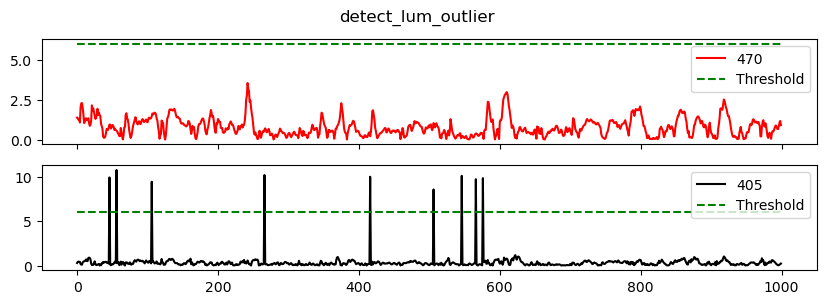

In [8]:
def pre_process_wrap(rawPath, mask=None, n_preview=None):
    """
    A wrapper function to pre-process the raw images.
    Args:
        rawPath: str, path to the raw images
        mask: np.array, brain mask
        n_preview: int or None, number of images to process for preview
    Returns:
        dff: np.array, delta F/F images

    """
    stack, files_470 = images2tiff_two_channel(rawPath, n_preview=n_preview,
        mask=mask,)

    stack_mean = np.mean(stack, axis=(2, 3))
    outlier_index_470, outlier_index_405 = detect_lum_outlier(stack_mean, 
        threshold=6, plot=True)
    
    if len(outlier_index_470) == 0 and len(outlier_index_405) == 0:
        print("No outliers detected, skipping correction step.")
        stack_corrected = stack
    else:
        stack_corrected = correct_lum_outlier(stack, outlier_index_470,
            outlier_index_405, plot=False)

    print("Calculating delta F/F of 470 channel...")
    stack_470_dff = delta_ff_3d(stack_corrected[:, 0, :, :], win=150)
    print("Calculating delta F/F of 405 channel...")
    stack_405_dff = delta_ff_3d(stack_corrected[:, 1, :, :], win=150)

    dff = stack_470_dff - stack_405_dff
    # Scale the dff to range of 16 bit
    dff_min = dff.min()
    dff_max = dff.max()
    dff = 65535 * (dff - dff_min) / (dff_max - dff_min)

    save_path = os.path.join(rawPath, 'dff.tif')
    imwrite(save_path, dff.astype(np.uint16), imagej=True)
    print('The dff tiff file saved to:', save_path)

    # return dff

pre_process_wrap(rawPath, mask=mask, n_preview=1000)